# Optimizer Benchmark Analysis

Loads CSV I/II/III and Wandb run histories to produce paper-ready plots.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import wandb

# ── Paths & constants ──────────────────────────────────────────────────────
RESULTS_DIR = "scripts/opt-bench/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

WANDB_ENTITY  = "matanbt"
WANDB_PROJECT = "tropt-optbench"

# Paper-style aesthetics
sns.set_theme(style="whitegrid", font_scale=1.2)
PALETTE = "tab20"
FIG_DPI = 150

## 1  Exp1: Optimization Dynamics

Line plot of loss over time per optimizer, for a chosen (model, message).
Shading = std across seeds. Dashed line = soft_prompt lower bound.

Only requires WandB access (no CSVs needed).

In [11]:
# ── Configuration ──────────────────────────────────────────────────────────
CHOSEN_MSG_ID = 1
CHOSEN_MODEL  = "meta-llama/Llama-3.1-8B-Instruct"  # set to your model
CHOSEN_MODEL = "google/gemma-3-12b-it"
CHOSEN_MODEL = "Qwen/Qwen3-8B"
    
    # "Qwen/Qwen3-8B"

api = wandb.Api()
runs = api.runs(
    f"{WANDB_ENTITY}/{WANDB_PROJECT}",
    filters={
        "state": "finished",
    },
)

# Keys to fetch from wandb (always include _runtime for time axis).
# NOTE: Do NOT include "step" — it is not logged; wandb provides "_step" automatically.
HISTORY_KEYS = ["loss", "best_loss", "total_models_stats/total_flops", "_runtime"]

# Collect per-step histories grouped by (optimizer, seed)
histories: dict[str, dict[int, pd.DataFrame]] = {}
lb_histories: dict[int, pd.DataFrame] = {}   # soft_prompt lower bound

for run in runs:
    # api.runs() lazy-loads runs without config; fetch it explicitly
    run.load_full_data()

    # Filter by config fields (now that config is populated)
    cfg = run.config
    if cfg.get("run_type") != "optbench_whitebox":
        continue
    if cfg.get("model_name") != CHOSEN_MODEL:
        continue
    if cfg.get("msg_id") != CHOSEN_MSG_ID:
        continue

    opt  = cfg.get("optimizer_name", "unknown")
    seed = cfg.get("seed", 0)
    is_soft = cfg.get("is_soft", False)

    try:
        hist = run.history(keys=HISTORY_KEYS, x_axis="_step", pandas=True)
    except Exception:
        hist = run.history(pandas=True)
    if hist.empty:
        continue
    # Normalise column names: _step -> step
    if "_step" in hist.columns:
        hist = hist.rename(columns={"_step": "step"})
    if "total_models_stats/total_flops" in hist.columns:
        hist = hist.rename(columns={"total_models_stats/total_flops": "flops"})
    if "_runtime" in hist.columns:
        hist = hist.rename(columns={"_runtime": "time"})
    if is_soft:
        lb_histories[seed] = hist
    else:
        histories.setdefault(opt, {})[seed] = hist

print(f"Loaded {sum(len(v) for v in histories.values())} runs for {len(histories)} optimizers")
if lb_histories:
    print(f"Loaded {len(lb_histories)} soft_prompt (lower-bound) runs")

wandb: WARNING A graphql request initiated by the public wandb API timed out (timeout=19 sec). Create a new API with an integer timeout larger than 19, e.g., `api = wandb.Api(timeout=29)` to increase the graphql timeout.
wandb: WARNING A graphql request initiated by the public wandb API timed out (timeout=19 sec). Create a new API with an integer timeout larger than 19, e.g., `api = wandb.Api(timeout=29)` to increase the graphql timeout.


Loaded 37 runs for 14 optimizers
Loaded 2 soft_prompt (lower-bound) runs


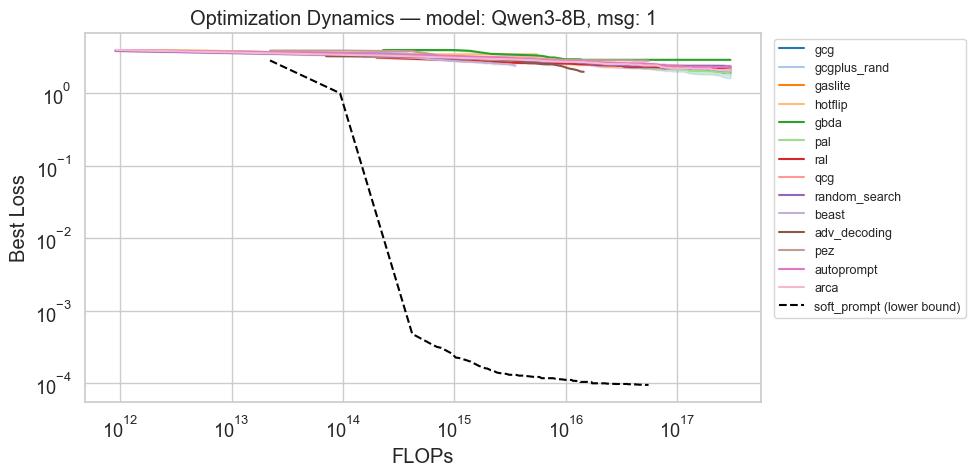

In [12]:
# ── Plot configuration ─────────────────────────────────────────────────────
X_AXIS = "flops"      # "time" (wall-clock seconds) or "flops"
Y_AXIS = "best_loss"  # "loss" (per-step) or "best_loss" (running best)

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette(PALETTE, len(histories))

for color, (opt_name, seed_hists) in zip(colors, histories.items()):
    # Resolve x column: prefer requested axis, fall back to step
    sample_cols = next(iter(seed_hists.values())).columns
    if X_AXIS in sample_cols:
        x_col = X_AXIS
    elif "step" in sample_cols:
        x_col = "step"
    else:
        x_col = sample_cols[0]
    # Align on common x grid by interpolating
    all_x = sorted(set(x for h in seed_hists.values() for x in h[x_col].dropna()))
    interp_losses = []
    for hist in seed_hists.values():
        valid = hist[[x_col, Y_AXIS]].dropna()
        if len(valid) < 2:
            continue
        interp_losses.append(np.interp(all_x, valid[x_col], valid[Y_AXIS]))
    if not interp_losses:
        continue
    arr = np.array(interp_losses)
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)
    ax.plot(all_x, mean, label=opt_name, color=color)
    ax.fill_between(all_x, mean - std, mean + std, alpha=0.15, color=color)

# Lower-bound dashed line
if lb_histories:
    sample_cols = next(iter(lb_histories.values())).columns
    x_col = X_AXIS if X_AXIS in sample_cols else "step"
    lb_losses = []
    all_x_lb = sorted(set(x for h in lb_histories.values() for x in h[x_col].dropna()))
    for hist in lb_histories.values():
        valid = hist[[x_col, Y_AXIS]].dropna()
        if len(valid) < 2:
            continue
        lb_losses.append(np.interp(all_x_lb, valid[x_col], valid[Y_AXIS]))
    if lb_losses:
        lb_mean = np.array(lb_losses).mean(axis=0)
        ax.plot(all_x_lb, lb_mean, linestyle="--", color="black", linewidth=1.5, label="soft_prompt (lower bound)")

X_LABELS = {"flops": "FLOPs", "time": "Wall-clock Time (s)"}
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(X_LABELS.get(X_AXIS, X_AXIS))
ax.set_ylabel(Y_AXIS.replace("_", " ").title())
ax.set_title(f"Optimization Dynamics — model: {CHOSEN_MODEL.split('/')[-1]}, msg: {CHOSEN_MSG_ID}")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
fig.savefig(f"{RESULTS_DIR}/fig_dynamics_m{CHOSEN_MSG_ID}.pdf", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

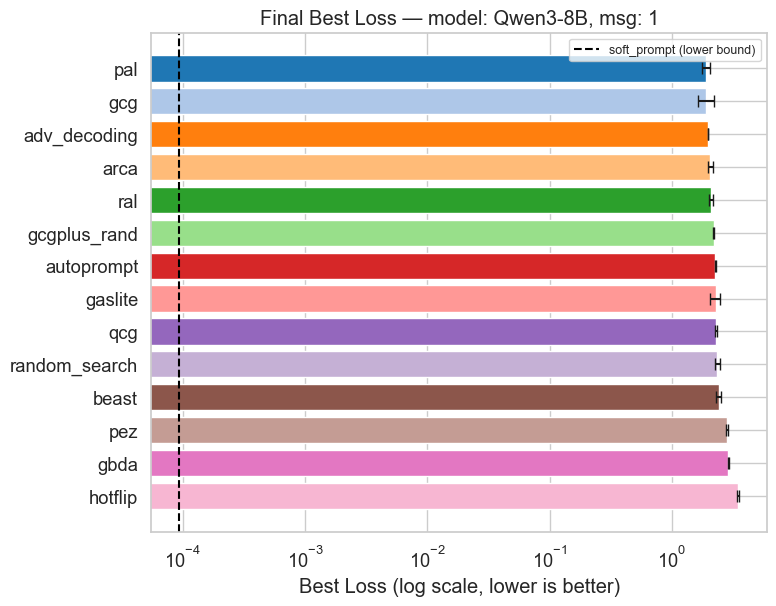

In [13]:
# ── Horizontal bar chart: final best_loss per optimizer ────────────────────
# Uses the same `histories` dict from the download cell above.
# Each bar = mean of final best_loss across seeds; error bar = std across seeds.

final_losses = {}
for opt_name, seed_hists in histories.items():
    finals = [h["best_loss"].iloc[-1] for h in seed_hists.values() if not h.empty]
    if finals:
        final_losses[opt_name] = finals

opts = sorted(final_losses.keys(), key=lambda o: np.mean(final_losses[o]))
means = [np.mean(final_losses[o]) for o in opts]
stds  = [np.std(final_losses[o]) for o in opts]

fig, ax = plt.subplots(figsize=(8, max(4, len(opts) * 0.45)))
colors = sns.color_palette(PALETTE, len(opts))
ax.barh(opts, means, xerr=stds, capsize=4, color=colors, edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Best Loss (log scale, lower is better)")
ax.set_title(f"Final Best Loss — model: {CHOSEN_MODEL.split('/')[-1]}, msg: {CHOSEN_MSG_ID}")
ax.invert_yaxis()

# Add lower-bound line if available
if lb_histories:
    lb_finals = [h["best_loss"].iloc[-1] for h in lb_histories.values() if not h.empty]
    if lb_finals:
        lb_mean = np.mean(lb_finals)
        ax.axvline(lb_mean, color="black", linestyle="--", linewidth=1.5, label="soft_prompt (lower bound)")
        ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(f"{RESULTS_DIR}/fig_bar_best_loss_m{CHOSEN_MSG_ID}.pdf", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

In [14]:
# ── Load CSVs (needed for sections 2+) ───────────────────────────────────
CSV_I_PATH  = f"{RESULTS_DIR}/csv_i.csv"
CSV_II_PATH = f"{RESULTS_DIR}/csv_ii.csv"
CSV_III_PATH = f"{RESULTS_DIR}/csv_iii.csv"

csv_i   = pd.read_csv(CSV_I_PATH)
csv_ii  = pd.read_csv(CSV_II_PATH)
csv_iii = pd.read_csv(CSV_III_PATH)

print(f"CSV I  rows: {len(csv_i)}")
print(f"CSV II rows: {len(csv_ii)}")
print(f"CSV III rows: {len(csv_iii)}")
print("Models:", csv_i["model_name"].unique().tolist())
print("Optimizers:", csv_i["optimizer_name"].unique().tolist())


FileNotFoundError: [Errno 2] No such file or directory: 'scripts/opt-bench/results/csv_i.csv'

## 2  Average Loss per Optimizer (CSV I)

Average final loss across all seeds and instructions.

In [ ]:
def bar_plot(df, value_col, title, ylabel, output_file=None,
             lower_bound_col=None, exclude_lower_bound=True):
    """Bar plot: avg value per optimizer, with std error bars."""
    plot_df = df.copy()
    if exclude_lower_bound and "is_lower_bound" in plot_df.columns:
        plot_df = plot_df[~plot_df["is_lower_bound"].astype(bool)]

    agg = (plot_df.groupby("optimizer_name")[value_col]
           .agg(["mean", "std", "count"])
           .reset_index()
           .sort_values("mean"))
    agg["se"] = agg["std"] / np.sqrt(agg["count"])

    fig, ax = plt.subplots(figsize=(max(8, len(agg) * 0.7), 5))
    colors = sns.color_palette(PALETTE, len(agg))
    bars = ax.bar(agg["optimizer_name"], agg["mean"], yerr=agg["se"],
                  capsize=4, color=colors, edgecolor="white")
    ax.set_xlabel("Optimizer")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    if output_file:
        fig.savefig(output_file, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
    return agg

agg_loss = bar_plot(csv_i, "best_loss", "Average Final Loss per Optimizer", "Loss (↓ better)",
                    output_file=f"{RESULTS_DIR}/fig_avg_loss.pdf")
agg_loss


## 3  Average BLEU per Optimizer (CSV II)

In [ ]:
agg_bleu = bar_plot(csv_ii, "bleu", "Average BLEU Score per Optimizer", "BLEU (↑ better)",
                    output_file=f"{RESULTS_DIR}/fig_avg_bleu.pdf")
agg_bleu


## 4  Average Universality per Optimizer (CSV III)

Universality = mean `strongreject_finetuned` score across ClearHarm messages.

In [ ]:
agg_univ = bar_plot(csv_iii, "strongreject_finetuned",
                    "Average Universality Score per Optimizer",
                    "Universality / Jailbreakness (↑ = more harmful)",
                    output_file=f"{RESULTS_DIR}/fig_avg_universality.pdf")
agg_univ


## 5  Box Plots

First average across seeds per (optimizer, model, msg_id) to reduce seed noise, then plot distribution across messages/models.

In [ ]:
# Filter control — set to None to include all models
FILTER_MODELS = None  # e.g. ["google/gemma-2-2b-it"]

def box_plot(df, value_col, title, ylabel, output_file=None,
             exclude_lower_bound=True):
    plot_df = df.copy()
    if exclude_lower_bound and "is_lower_bound" in plot_df.columns:
        plot_df = plot_df[~plot_df["is_lower_bound"].astype(bool)]
    if FILTER_MODELS:
        plot_df = plot_df[plot_df["model_name"].isin(FILTER_MODELS)]

    # Average across seeds first
    seed_avg = (plot_df.groupby(["optimizer_name", "model_name", "msg_id"])[value_col]
                .mean().reset_index())

    fig, ax = plt.subplots(figsize=(max(8, seed_avg["optimizer_name"].nunique() * 0.9), 5))
    order = (seed_avg.groupby("optimizer_name")[value_col].median()
             .sort_values().index.tolist())
    sns.boxplot(data=seed_avg, x="optimizer_name", y=value_col, order=order,
                palette=PALETTE, ax=ax, width=0.6)
    ax.set_xlabel("Optimizer")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    if output_file:
        fig.savefig(output_file, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

box_plot(csv_i,   "best_loss",              "Loss Distribution per Optimizer",         "Loss (↓ better)",
         f"{RESULTS_DIR}/fig_box_loss.pdf")
box_plot(csv_ii,  "bleu",                   "BLEU Distribution per Optimizer",          "BLEU (↑ better)",
         f"{RESULTS_DIR}/fig_box_bleu.pdf")
box_plot(csv_iii, "strongreject_finetuned", "Universality Distribution per Optimizer", "Universality (↑ = more harmful)",
         f"{RESULTS_DIR}/fig_box_universality.pdf")


## 6  LaTeX Table

Rows = optimizers, columns = models, cell = avg across seeds & instructions. Winners per column are marked in **bold**.

In [ ]:
METRIC_COL = "best_loss"  # swap to "bleu" or "strongreject_finetuned" for other metrics
METRIC_LOWER_IS_BETTER = True  # set False for BLEU / universality

df_tab = csv_i.copy()
if "is_lower_bound" in df_tab.columns:
    df_tab = df_tab[~df_tab["is_lower_bound"].astype(bool)]

# Average across seeds and msg_ids per (optimizer, model)
pivot = (df_tab.groupby(["optimizer_name", "model_name"])[METRIC_COL]
         .mean().unstack("model_name"))

# Add overall average column
pivot["Avg"] = pivot.mean(axis=1)
pivot = pivot.sort_values("Avg", ascending=METRIC_LOWER_IS_BETTER)

# Build LaTeX
model_cols = [c for c in pivot.columns if c != "Avg"]
header_row = " & ".join(["Optimizer"] + [c.split("/")[-1] for c in model_cols] + ["Avg"]) + r" \"

rows_latex = []
for opt, row in pivot.iterrows():
    vals = [row[c] for c in model_cols] + [row["Avg"]]
    # Find winner (min or max) per column
    formatted = []
    for col_idx, (col, v) in enumerate(zip(model_cols + ["Avg"], vals)):
        col_vals = pivot[col].dropna()
        is_winner = (v == col_vals.min()) if METRIC_LOWER_IS_BETTER else (v == col_vals.max())
        cell = f"\\textbf{{{v:.3f}}}" if is_winner else f"{v:.3f}"
        formatted.append(cell)
    rows_latex.append(f"    {opt} & " + " & ".join(formatted) + r" \\")

print(r"\begin{table}[h]")
print(r"\centering")
print(r"\caption{Optimizer Benchmark — " + METRIC_COL + "}")
print(r"\begin{tabular}{l" + "r" * (len(model_cols) + 1) + "}")
print(r"\toprule")
print(f"    {header_row}")
print(r"\midrule")
for r in rows_latex:
    print(r)
print(r"\bottomrule")
print(r"\end{tabular}")
print(r"\end{table}")


---
# Exp2: Jailbreak Tweaks Analysis

Load exp2 CSVs (single and multi-instruction). Group by `variant_name` instead of `optimizer_name`.

**Controls**: Set `EXP2_RESULTS_DIR` and CSV filenames below to match your `run_all.sh` output.

In [ ]:
# ── Exp2 Configuration ──────────────────────────────────────────────
EXP2_RESULTS_DIR = RESULTS_DIR  # same dir by default

# Single-instruction CSVs (set per model, e.g. exp2_single_Llama-3.1-8B-Instruct_csv_i.csv)
EXP2_SINGLE_CSV_I   = f"{EXP2_RESULTS_DIR}/exp2_single_csv_i.csv"   # adjust filename
EXP2_SINGLE_CSV_II  = f"{EXP2_RESULTS_DIR}/exp2_single_csv_ii.csv"
EXP2_SINGLE_CSV_III = f"{EXP2_RESULTS_DIR}/exp2_single_csv_iii.csv"

# Multi-instruction CSVs
EXP2_MULTI_CSV_I   = f"{EXP2_RESULTS_DIR}/exp2_multi_csv_i.csv"
EXP2_MULTI_CSV_III = f"{EXP2_RESULTS_DIR}/exp2_multi_csv_iii.csv"

# Load
import os
exp2s_i   = pd.read_csv(EXP2_SINGLE_CSV_I)   if os.path.exists(EXP2_SINGLE_CSV_I)   else pd.DataFrame()
exp2s_ii  = pd.read_csv(EXP2_SINGLE_CSV_II)  if os.path.exists(EXP2_SINGLE_CSV_II)  else pd.DataFrame()
exp2s_iii = pd.read_csv(EXP2_SINGLE_CSV_III) if os.path.exists(EXP2_SINGLE_CSV_III) else pd.DataFrame()
exp2m_i   = pd.read_csv(EXP2_MULTI_CSV_I)    if os.path.exists(EXP2_MULTI_CSV_I)    else pd.DataFrame()
exp2m_iii = pd.read_csv(EXP2_MULTI_CSV_III)   if os.path.exists(EXP2_MULTI_CSV_III)  else pd.DataFrame()

for name, df in [("exp2 single I", exp2s_i), ("exp2 single II", exp2s_ii),
                  ("exp2 single III", exp2s_iii), ("exp2 multi I", exp2m_i),
                  ("exp2 multi III", exp2m_iii)]:
    print(f"{name}: {len(df)} rows")

## Exp2 Single-Instruction: Loss, BLEU, Universality

Same plots as exp1 but grouped by `variant_name`.

In [ ]:
GROUP_COL = "variant_name"  # exp2 groups by variant, not optimizer

def bar_plot_exp2(df, value_col, title, ylabel, group_col=GROUP_COL, output_file=None):
    if df.empty:
        print(f"No data for: {title}")
        return
    agg = (df.groupby(group_col)[value_col]
           .agg(["mean", "std", "count"]).reset_index().sort_values("mean"))
    agg["se"] = agg["std"] / np.sqrt(agg["count"])
    fig, ax = plt.subplots(figsize=(max(8, len(agg) * 0.9), 5))
    colors = sns.color_palette(PALETTE, len(agg))
    ax.bar(agg[group_col], agg["mean"], yerr=agg["se"], capsize=4,
           color=colors, edgecolor="white")
    ax.set_xlabel("Variant")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    if output_file:
        fig.savefig(output_file, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
    return agg

bar_plot_exp2(exp2s_i,   "best_loss",              "Exp2 Single: Avg Loss per Variant",         "Loss")
bar_plot_exp2(exp2s_ii,  "bleu",                   "Exp2 Single: Avg BLEU per Variant",         "BLEU")
bar_plot_exp2(exp2s_iii, "strongreject_finetuned", "Exp2 Single: Avg Universality per Variant", "Universality")

## Exp2 Multi-Instruction: Loss & Universality

Multi-instruction runs produce a single universal trigger per variant. 
CSV III universality is the primary metric here.

In [ ]:
bar_plot_exp2(exp2m_i,   "best_loss",              "Exp2 Multi: Avg Loss per Variant",         "Loss")
bar_plot_exp2(exp2m_iii, "strongreject_finetuned", "Exp2 Multi: Avg Universality per Variant", "Universality")

## Exp2 Box Plots (Single-Instruction)

Averaged across seeds, distribution across messages and models.

In [ ]:
def box_plot_exp2(df, value_col, title, ylabel, group_col=GROUP_COL, output_file=None):
    if df.empty:
        print(f"No data for: {title}")
        return
    seed_avg = (df.groupby([group_col, "model_name", "msg_id"])[value_col]
                .mean().reset_index())
    fig, ax = plt.subplots(figsize=(max(8, seed_avg[group_col].nunique() * 0.9), 5))
    order = (seed_avg.groupby(group_col)[value_col].median()
             .sort_values().index.tolist())
    sns.boxplot(data=seed_avg, x=group_col, y=value_col, order=order,
                palette=PALETTE, ax=ax, width=0.6)
    ax.set_xlabel("Variant")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    if output_file:
        fig.savefig(output_file, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

box_plot_exp2(exp2s_i,   "best_loss",              "Exp2: Loss Distribution per Variant",         "Loss")
box_plot_exp2(exp2s_ii,  "bleu",                   "Exp2: BLEU Distribution per Variant",          "BLEU")
box_plot_exp2(exp2s_iii, "strongreject_finetuned", "Exp2: Universality Distribution per Variant", "Universality")

## Exp2 Optimization Dynamics (Single-Instruction)

Same as exp1 dynamics plot but filtered by `tweakbench_single` run type. Lines = variants.

In [ ]:
# ── Configuration ──────────────────────────────────────────────────────────
EXP2_CHOSEN_MSG_ID = 0
EXP2_CHOSEN_MODEL  = exp2s_i["model_name"].iloc[0] if not exp2s_i.empty else "N/A"
EXP2_X_AXIS = "step"  # "step" or "flops"
EXP2_Y_AXIS = "best_loss"  # "loss" (per-step) or "best_loss" (running best)

print(f"Available msg_ids: {sorted(exp2s_i['msg_id'].dropna().unique().tolist()) if not exp2s_i.empty else []}")
print(f"Available models:  {exp2s_i['model_name'].unique().tolist() if not exp2s_i.empty else []}")

if not exp2s_i.empty:
    api = wandb.Api()
    runs = api.runs(
        f"{WANDB_ENTITY}/{WANDB_PROJECT}",
        filters={
            "state": "finished",
            "config.run_type": "tweakbench_single",
            "config.model_name": EXP2_CHOSEN_MODEL,
            "config.msg_id": EXP2_CHOSEN_MSG_ID,
        },
    )
    histories = {}
    for run in runs:
        var  = run.config.get("variant_name", "unknown")
        seed = run.config.get("seed", 0)
        try:
            hist = run.history(keys=["loss", "best_loss", "step", "total_models_stats/total_flops"], x_axis="_step", pandas=True)
        except Exception:
            hist = run.history(pandas=True)
        if hist.empty:
            continue
        if "step" not in hist.columns and "_step" in hist.columns:
            hist = hist.rename(columns={"_step": "step"})
        if "total_models_stats/total_flops" in hist.columns:
            hist = hist.rename(columns={"total_models_stats/total_flops": "flops"})
        histories.setdefault(var, {})[seed] = hist

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = sns.color_palette(PALETTE, len(histories))
    for color, (var_name, seed_hists) in zip(colors, histories.items()):
        x_col = "flops" if (EXP2_X_AXIS == "flops" and "flops" in next(iter(seed_hists.values())).columns) else "step"
        all_x = sorted(set(x for h in seed_hists.values() for x in h[x_col].dropna()))
        interp_losses = []
        for hist in seed_hists.values():
            valid = hist[[x_col, EXP2_Y_AXIS]].dropna()
            if len(valid) < 2:
                continue
            interp_losses.append(np.interp(all_x, valid[x_col], valid[EXP2_Y_AXIS]))
        if not interp_losses:
            continue
        arr = np.array(interp_losses)
        mean, std = arr.mean(axis=0), arr.std(axis=0)
        ax.plot(all_x, mean, label=var_name, color=color)
        ax.fill_between(all_x, mean - std, mean + std, alpha=0.15, color=color)
    ax.set_xlabel("FLOPs" if EXP2_X_AXIS == "flops" else "Step")
    ax.set_ylabel(EXP2_Y_AXIS.replace("_", " ").title())
    ax.set_title(f"Exp2 Dynamics — {EXP2_CHOSEN_MODEL.split('/')[-1]}, msg {EXP2_CHOSEN_MSG_ID}")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("No exp2 single-instruction data available.")


## Exp2 LaTeX Table (Single-Instruction)

Rows = variants, columns = models, cell = avg across seeds & instructions.

In [ ]:
EXP2_METRIC_COL = "best_loss"  # swap to "bleu" or "strongreject_finetuned"
EXP2_METRIC_LOWER_IS_BETTER = True

if not exp2s_i.empty:
    pivot = (exp2s_i.groupby(["variant_name", "model_name"])[EXP2_METRIC_COL]
             .mean().unstack("model_name"))
    pivot["Avg"] = pivot.mean(axis=1)
    pivot = pivot.sort_values("Avg", ascending=EXP2_METRIC_LOWER_IS_BETTER)
    model_cols = [c for c in pivot.columns if c != "Avg"]
    header = " & ".join(["Variant"] + [c.split("/")[-1] for c in model_cols] + ["Avg"]) + r" \\"
    rows_latex = []
    for var, row in pivot.iterrows():
        vals = [row[c] for c in model_cols] + [row["Avg"]]
        formatted = []
        for col, v in zip(model_cols + ["Avg"], vals):
            col_vals = pivot[col].dropna()
            is_winner = (v == col_vals.min()) if EXP2_METRIC_LOWER_IS_BETTER else (v == col_vals.max())
            formatted.append(f"\\textbf{{{v:.3f}}}" if is_winner else f"{v:.3f}")
        rows_latex.append(f"    {var} & " + " & ".join(formatted) + r" \\")
    print(r"\begin{table}[h]")
    print(r"\centering")
    print(r"\caption{Jailbreak Tweaks — " + EXP2_METRIC_COL + "}")
    print(r"\begin{tabular}{l" + "r" * (len(model_cols) + 1) + "}")
    print(r"\toprule")
    print(f"    {header}")
    print(r"\midrule")
    for r in rows_latex:
        print(r)
    print(r"\bottomrule")
    print(r"\end{tabular}")
    print(r"\end{table}")
else:
    print("No exp2 data available.")